# Préparation des données v2


## Position retenue

Ce notebook applique explicitement la logique méthodologique suivante :

- `crop_yield.csv` est retenu comme **dataset d'analyse amont** : nettoyage, compréhension métier et ACP de cadrage analytique ;
- le dossier `Crop Yield Prediction Dataset` est retenu comme **base annuelle de consolidation** pour la modélisation ;
- `yield.csv` sert de table de base annuelle, enrichie ensuite par `rainfall.csv`, `pesticides.csv` et `temp.csv` ;
- `yield_df.csv` sert uniquement de **fichier d'audit** pour contrôler la cohérence du scénario de fusion ;
- `crop_yield.csv` n'est **pas** fusionné directement avec `yield_df.csv`, car il ne contient ni `area/country` ni `year`, donc la jointure ne serait pas fiable ;
- le périmètre temporel des tables annuelles est borné à partir de `1990` ;
- l'ACP est réalisée **après nettoyage**, sur les variables quantitatives explicatives de `crop_yield.csv`, et ses composantes ne sont pas réinjectées dans le dataset final de modélisation.


- quelles variables semblent liées au rendement agricole ;
- quelles données annuelles peuvent être fusionnées de manière fiable ;
- quel jeu de données final est suffisamment propre pour alimenter la modélisation.

L'objectif est de passer d'un ensemble de sources hétérogènes à une base exploitable, compréhensible et défendable d'un point de vue métier.


## Imports et configuration générale

Les imports ci-dessous couvrent uniquement la préparation, l'audit et l'ACP de cadrage analytique.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scripts.project_config import DEFAULT_CONFIG_PATH, load_preparation_config

try:
    from IPython.display import display
except ModuleNotFoundError:
    def display(obj):
        print(obj)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
SEED = 42


## Configuration et chemins

Les chemins sources et de sortie de l'étape de préparation sont maintenant centralisés dans `config/project_paths.yaml`.


In [2]:
preparation_config = load_preparation_config(ensure_dirs=True)
AGRI_CROP_YIELD_PATH = preparation_config["AGRI_CROP_YIELD_PATH"]
YIELD_PATH = preparation_config["YIELD_PATH"]
RAINFALL_PATH = preparation_config["RAINFALL_PATH"]
PESTICIDES_PATH = preparation_config["PESTICIDES_PATH"]
TEMP_PATH = preparation_config["TEMP_PATH"]
YIELD_DF_AUDIT_PATH = preparation_config["YIELD_DF_AUDIT_PATH"]
DATASET_PATH = preparation_config["DATASET_PATH"]
ARTIFACTS_DIR = preparation_config["ARTIFACTS_DIR"]
PCA_ARTIFACTS_DIR = preparation_config["PCA_ARTIFACTS_DIR"]
PCA_CORRELATION_TABLE_PATH = preparation_config["PCA_CORRELATION_TABLE_PATH"]
PCA_PC1_CONTRIBUTIONS_PATH = preparation_config["PCA_PC1_CONTRIBUTIONS_PATH"]
PCA_VARIANCE_TABLE_PATH = preparation_config["PCA_VARIANCE_TABLE_PATH"]
PCA_SUMMARY_PATH = preparation_config["PCA_SUMMARY_PATH"]
PCA_CORRELATION_FIG_PATH = preparation_config["PCA_CORRELATION_FIG_PATH"]
PCA_LOADINGS_FIG_PATH = preparation_config["PCA_LOADINGS_FIG_PATH"]
PCA_VARIANCE_FIG_PATH = preparation_config["PCA_VARIANCE_FIG_PATH"]
MIN_YEAR = int(preparation_config["MIN_YEAR"])

ARTIFACTS_DIR.mkdir(exist_ok=True)
PCA_ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
DATASET_PATH.parent.mkdir(parents=True, exist_ok=True)

print(f"Configuration chargée depuis : {DEFAULT_CONFIG_PATH.resolve()}")
print(f"Agriculture CropYield : {AGRI_CROP_YIELD_PATH}")
print(f"Base rendement : {YIELD_PATH}")
print(f"Pluie : {RAINFALL_PATH}")
print(f"Pesticides : {PESTICIDES_PATH}")
print(f"Température : {TEMP_PATH}")
print(f"Audit : {YIELD_DF_AUDIT_PATH}")
print(f"Dataset consolidé : {DATASET_PATH}")
print(f"Dossier artefacts : {ARTIFACTS_DIR}")
print(f"Artefacts ACP : {PCA_ARTIFACTS_DIR}")
print(f"Seuil minimal retenu pour les données annuelles : {MIN_YEAR}")


Configuration chargée depuis : /Users/steph/Code/Python/Jupyter/OCR_Projet12/config/project_paths.yaml
Agriculture CropYield : /Users/steph/Code/Python/Jupyter/OCR_Projet12/data/crop_yield.csv
Base rendement : /Users/steph/Code/Python/Jupyter/OCR_Projet12/data/Crop Yield Prediction Dataset/yield.csv
Pluie : /Users/steph/Code/Python/Jupyter/OCR_Projet12/data/Crop Yield Prediction Dataset/rainfall.csv
Pesticides : /Users/steph/Code/Python/Jupyter/OCR_Projet12/data/Crop Yield Prediction Dataset/pesticides.csv
Température : /Users/steph/Code/Python/Jupyter/OCR_Projet12/data/Crop Yield Prediction Dataset/temp.csv
Audit : /Users/steph/Code/Python/Jupyter/OCR_Projet12/data/Crop Yield Prediction Dataset/yield_df.csv
Dataset consolidé : /Users/steph/Code/Python/Jupyter/OCR_Projet12/data/dataset_consolide.csv
Dossier artefacts : /Users/steph/Code/Python/Jupyter/OCR_Projet12/artifacts
Artefacts ACP : /Users/steph/Code/Python/Jupyter/OCR_Projet12/artifacts/pca
Seuil minimal retenu pour les données

## 1. `crop_yield.csv` : nettoyage et préparation du dataset d'analyse

Cette section prépare `crop_yield.csv` comme base d'analyse explicative. Le but n'est pas de le fusionner artificiellement avec les tables annuelles, mais d'en extraire une lecture fiable des facteurs agronomiques et climatiques avant la modélisation.


### Pourquoi commencer par `crop_yield.csv`

`crop_yield.csv` est utile pour une première lecture métier parce qu'il rassemble déjà, dans un même fichier, des informations de pluie, de température, d'irrigation, de fertilisation, de durée de culture et de rendement.

Cela permet de répondre à une question simple : **quels facteurs semblent aller de pair avec des rendements plus élevés ou plus faibles ?**

En revanche, ce fichier ne contient pas de clé géographique ni d'année. Il aide donc à comprendre les mécanismes du rendement, mais pas à reconstruire une histoire annuelle fiable par pays et par culture.


In [3]:
agriculture_crop_yield_raw = pd.read_csv(AGRI_CROP_YIELD_PATH)

agri_raw_memory_mb = agriculture_crop_yield_raw.memory_usage(deep=True).sum() / 1024**2
agri_raw_audit = pd.DataFrame(
    {
        'indicateur': [
            'nb_lignes',
            'nb_colonnes',
            'valeurs_manquantes',
            'doublons_lignes',
            'doublons_colonnes',
            'rendements_negatifs',
            'memoire_mb',
        ],
        'valeur': [
            agriculture_crop_yield_raw.shape[0],
            agriculture_crop_yield_raw.shape[1],
            int(agriculture_crop_yield_raw.isna().sum().sum()),
            int(agriculture_crop_yield_raw.duplicated().sum()),
            int(pd.Index(agriculture_crop_yield_raw.columns).duplicated().sum()),
            int((agriculture_crop_yield_raw['Yield_tons_per_hectare'] < 0).sum()),
            round(agri_raw_memory_mb, 2),
        ],
    }
)
display(agri_raw_audit)

agriculture_crop_yield_clean = agriculture_crop_yield_raw.copy().rename(
    columns={
        'Region': 'region',
        'Soil_Type': 'soil_type',
        'Crop': 'crop',
        'Rainfall_mm': 'rainfall_mm',
        'Temperature_Celsius': 'temperature_celsius',
        'Fertilizer_Used': 'fertilizer_used',
        'Irrigation_Used': 'irrigation_used',
        'Weather_Condition': 'weather_condition',
        'Days_to_Harvest': 'days_to_harvest',
        'Yield_tons_per_hectare': 'yield_tons_per_hectare',
    }
)

target_col = 'yield_tons_per_hectare'
agri_categorical_cols = ['region', 'soil_type', 'crop', 'weather_condition']
pca_numeric_cols = ['rainfall_mm', 'temperature_celsius', 'days_to_harvest']
quantitative_analysis_cols = pca_numeric_cols + [target_col]

agriculture_crop_yield_clean[agri_categorical_cols] = agriculture_crop_yield_clean[agri_categorical_cols].apply(
    lambda col: col.astype(str).str.strip()
)
agriculture_crop_yield_clean[quantitative_analysis_cols] = agriculture_crop_yield_clean[quantitative_analysis_cols].apply(
    pd.to_numeric, errors='coerce'
)

for col in agri_categorical_cols:
    agriculture_crop_yield_clean[col] = agriculture_crop_yield_clean[col].astype('category')

agriculture_crop_yield_clean['fertilizer_used'] = agriculture_crop_yield_clean['fertilizer_used'].astype(bool)
agriculture_crop_yield_clean['irrigation_used'] = agriculture_crop_yield_clean['irrigation_used'].astype(bool)

nb_negative_removed = int((agriculture_crop_yield_clean[target_col] < 0).sum())
agriculture_crop_yield_clean = agriculture_crop_yield_clean.loc[
    agriculture_crop_yield_clean[target_col] >= 0
].reset_index(drop=True)

agri_cleaning_log = pd.DataFrame(
    [
        {
            'operation': 'Renommage des colonnes en snake_case',
            'impact': 'standardisation des noms',
            'nb_lignes_impactees': 0,
        },
        {
            'operation': 'Suppression des espaces parasites sur les colonnes textuelles',
            'impact': 'harmonisation des modalites',
            'nb_lignes_impactees': 0,
        },
        {
            'operation': 'Conversion des colonnes textuelles en category',
            'impact': 'meilleure lisibilite et optimisation memoire',
            'nb_lignes_impactees': 0,
        },
        {
            'operation': 'Conservation des colonnes booleennes en bool',
            'impact': 'coherence metier des indicateurs oui/non',
            'nb_lignes_impactees': 0,
        },
        {
            'operation': 'Suppression des rendements negatifs',
            'impact': 'retrait des valeurs incoherentes',
            'nb_lignes_impactees': nb_negative_removed,
        },
    ]
)

display(agri_cleaning_log)

afri_clean_memory_mb = agriculture_crop_yield_clean.memory_usage(deep=True).sum() / 1024**2
agri_before_after = pd.DataFrame(
    {
        'etape': ['avant_nettoyage', 'apres_nettoyage'],
        'nb_lignes': [agriculture_crop_yield_raw.shape[0], agriculture_crop_yield_clean.shape[0]],
        'nb_colonnes': [agriculture_crop_yield_raw.shape[1], agriculture_crop_yield_clean.shape[1]],
        'valeurs_manquantes': [
            int(agriculture_crop_yield_raw.isna().sum().sum()),
            int(agriculture_crop_yield_clean.isna().sum().sum()),
        ],
        'doublons_lignes': [
            int(agriculture_crop_yield_raw.duplicated().sum()),
            int(agriculture_crop_yield_clean.duplicated().sum()),
        ],
        'rendements_negatifs': [
            int((agriculture_crop_yield_raw['Yield_tons_per_hectare'] < 0).sum()),
            int((agriculture_crop_yield_clean[target_col] < 0).sum()),
        ],
        'memoire_mb': [round(agri_raw_memory_mb, 2), round(afri_clean_memory_mb, 2)],
    }
)

display(agri_before_after)
display(agriculture_crop_yield_clean.head(3))


,indicateur,valeur
0,nb_lignes,1000000.00
1,nb_colonnes,10.00
2,valeurs_manquantes,0.00
3,doublons_lignes,0.00
4,doublons_colonnes,0.00
5,rendements_negatifs,231.00
6,memoire_mb,238.42


,operation,impact,nb_lignes_impactees
0,Renommage des colonnes en snake_case,standardisation des noms,0
1,Suppression des espaces parasites sur les colo...,harmonisation des modalites,0
2,Conversion des colonnes textuelles en category,meilleure lisibilite et optimisation memoire,0
3,Conservation des colonnes booleennes en bool,coherence metier des indicateurs oui/non,0
4,Suppression des rendements negatifs,retrait des valeurs incoherentes,231


,etape,nb_lignes,nb_colonnes,valeurs_manquantes,doublons_lignes,rendements_negatifs,memoire_mb
0,avant_nettoyage,1000000,10,0,0,231,238.42
1,apres_nettoyage,999769,10,0,0,0,36.23


,region,soil_type,crop,rainfall_mm,temperature_celsius,fertilizer_used,irrigation_used,weather_condition,days_to_harvest,yield_tons_per_hectare
0,West,Sandy,Cotton,897.077239,27.676966,False,True,Cloudy,122,6.555816
1,South,Clay,Rice,992.673282,18.026142,True,True,Rainy,140,8.527341
2,North,Loam,Barley,147.998025,29.794042,False,False,Sunny,106,1.127443


## 2. ACP après nettoyage sur `crop_yield.csv`

Cette ACP répond à la demande du brief sur `Agriculture CropYield`. Elle est utilisée ici comme **outil de cadrage analytique** pour identifier les dimensions quantitatives explicatives les plus structurantes.

Variables actives retenues :

- `rainfall_mm`
- `temperature_celsius`
- `days_to_harvest`

Le rendement reste une **variable de lecture** pour interpréter les axes, mais n'entre pas comme variable active dans l'ACP.


### Comment lire cette ACP dans un langage métier

Ici, l'ACP ne sert pas à fabriquer des variables pour le modèle final. Elle sert à simplifier la lecture de plusieurs variables quantitatives à la fois.

En pratique, elle aide à voir si la pluie, la température et la durée du cycle cultural évoluent dans le même sens, dans des sens opposés, ou de façon indépendante.

Pour un public métier, l'intérêt est surtout de produire une **vue synthétique des facteurs structurants** avant de passer à la consolidation des données annuelles.


,rainfall_mm,temperature_celsius,days_to_harvest
rainfall_mm,1.000,-0.000,-0.003
temperature_celsius,-0.000,1.000,-0.001
days_to_harvest,-0.003,-0.001,1.000


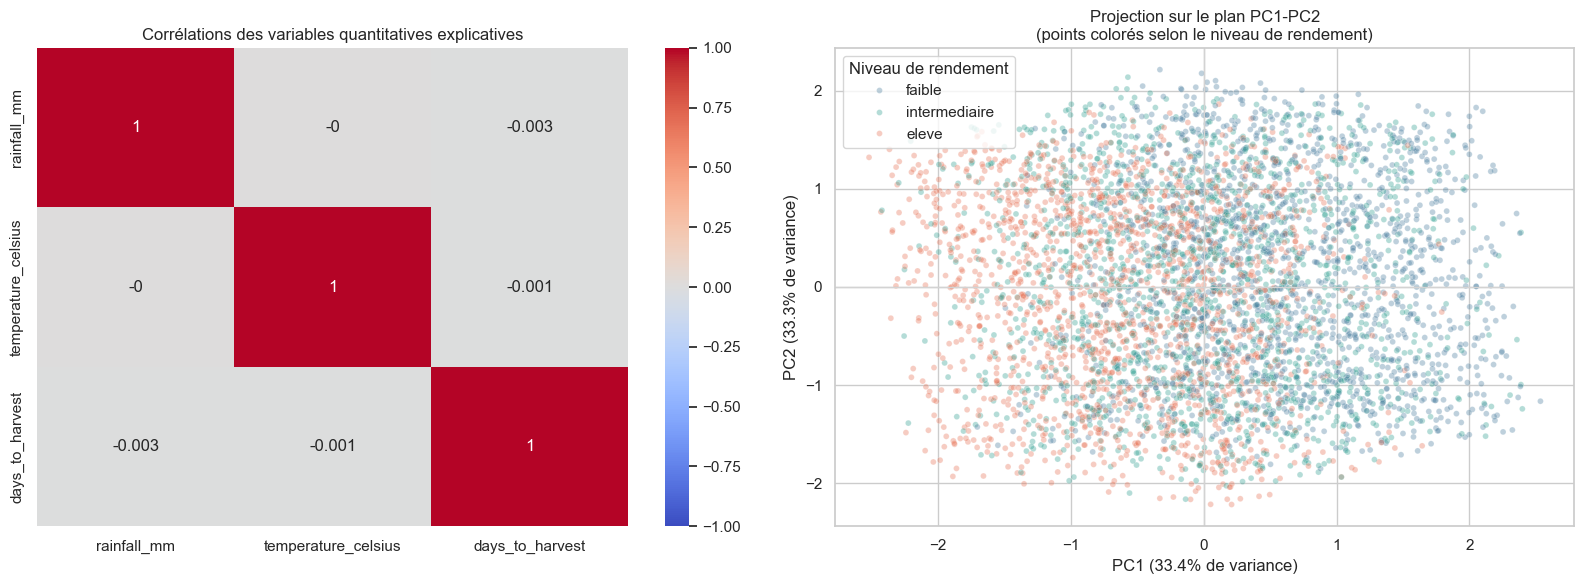

In [4]:
pca_input = agriculture_crop_yield_clean[pca_numeric_cols].copy()
pca_scaler = StandardScaler()
pca_scaled = pca_scaler.fit_transform(pca_input)

pca_model = PCA()
pca_features = pca_model.fit_transform(pca_scaled)

pca_scores = pd.DataFrame(
    pca_features,
    columns=[f'PC{i + 1}' for i in range(len(pca_numeric_cols))],
)
q1, q2 = agriculture_crop_yield_clean[target_col].quantile([0.33, 0.66]).tolist()
pca_scores['yield_level'] = pd.cut(
    agriculture_crop_yield_clean[target_col],
    bins=[-np.inf, q1, q2, np.inf],
    labels=['faible', 'intermediaire', 'eleve'],
    include_lowest=True,
)
pca_scores_sample = pca_scores.sample(n=min(5000, len(pca_scores)), random_state=SEED)

pca_correlation = pca_input.corr().round(3)
pca_correlation.to_csv(PCA_CORRELATION_TABLE_PATH)
display(pca_correlation)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(
    pca_correlation,
    annot=True,
    cmap='coolwarm',
    center=0,
    vmin=-1,
    vmax=1,
    ax=axes[0],
)
axes[0].set_title('Corrélations des variables quantitatives explicatives')

sns.scatterplot(
    data=pca_scores_sample,
    x='PC1',
    y='PC2',
    hue='yield_level',
    palette={'faible': '#457b9d', 'intermediaire': '#2a9d8f', 'eleve': '#e76f51'},
    alpha=0.35,
    s=18,
    ax=axes[1],
)
axes[1].set_title('Projection sur le plan PC1-PC2\n(points colorés selon le niveau de rendement)')
axes[1].set_xlabel(f"PC1 ({pca_model.explained_variance_ratio_[0]:.1%} de variance)")
axes[1].set_ylabel(f"PC2 ({pca_model.explained_variance_ratio_[1]:.1%} de variance)")
axes[1].axhline(0, color='lightgray', linewidth=1)
axes[1].axvline(0, color='lightgray', linewidth=1)
axes[1].legend(title='Niveau de rendement', loc='best')

plt.tight_layout()
fig.savefig(PCA_CORRELATION_FIG_PATH, dpi=150, bbox_inches='tight')
plt.show()


,variable,contribution_absolue_pc1
0,days_to_harvest,0.715
1,rainfall_mm,0.693
2,temperature_celsius,0.104


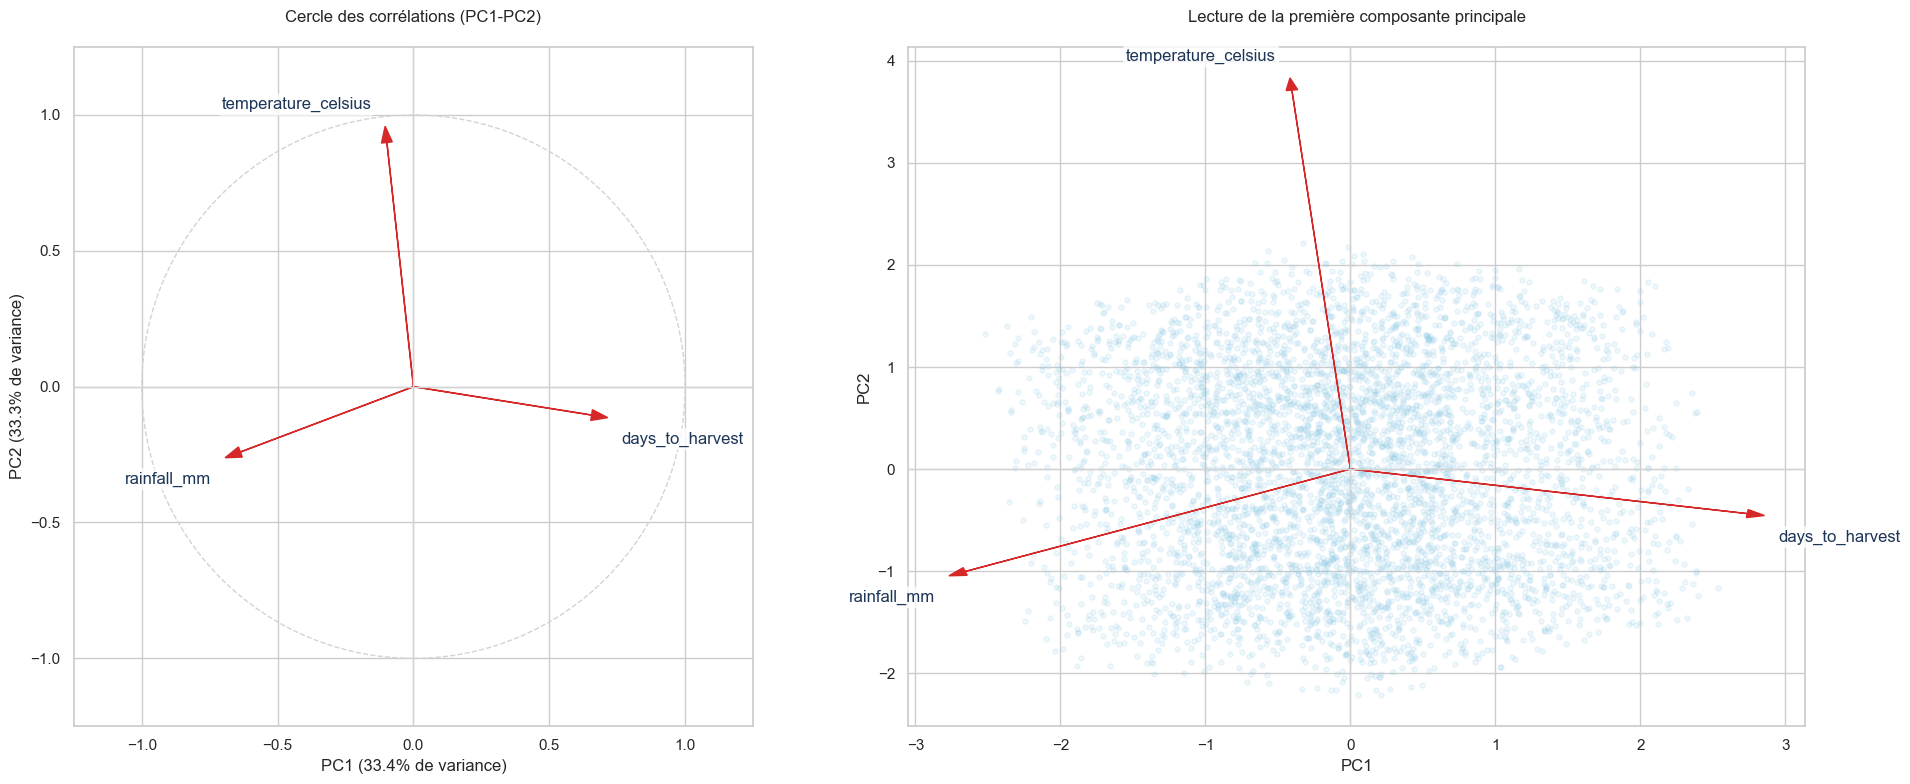

In [5]:
pca_loadings = pd.DataFrame(
    pca_model.components_.T,
    index=pca_numeric_cols,
    columns=[f'PC{i + 1}' for i in range(len(pca_numeric_cols))],
)
pca_variable_coords = pd.DataFrame(
    pca_model.components_.T * np.sqrt(pca_model.explained_variance_),
    index=pca_numeric_cols,
    columns=[f'PC{i + 1}' for i in range(len(pca_numeric_cols))],
)

pc1_contributions = (
    pca_variable_coords['PC1']
    .abs()
    .sort_values(ascending=False)
    .rename('contribution_absolue_pc1')
    .to_frame()
    .reset_index()
    .rename(columns={'index': 'variable'})
)
pc1_contributions.to_csv(PCA_PC1_CONTRIBUTIONS_PATH, index=False)
display(pc1_contributions.round(3))

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

correlation_circle = plt.Circle((0, 0), 1, color='lightgray', fill=False, linestyle='--')
axes[0].add_patch(correlation_circle)

for variable in pca_numeric_cols:
    x = pca_variable_coords.loc[variable, 'PC1']
    y = pca_variable_coords.loc[variable, 'PC2']
    axes[0].arrow(0, 0, x, y, color='#d62828', head_width=0.04, length_includes_head=True)
    axes[0].annotate(
        variable,
        xy=(x, y),
        xytext=(10 if x >= 0 else -10, 10 if y >= 0 else -10),
        textcoords='offset points',
        color='#1d3557',
        ha='left' if x >= 0 else 'right',
        va='bottom' if y >= 0 else 'top',
        bbox=dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor='none', alpha=0.8),
    )

axes[0].set_title('Cercle des corrélations (PC1-PC2)', pad=18)
axes[0].set_xlabel(f"PC1 ({pca_model.explained_variance_ratio_[0]:.1%} de variance)")
axes[0].set_ylabel(f"PC2 ({pca_model.explained_variance_ratio_[1]:.1%} de variance)")
axes[0].set_xlim(-1.25, 1.25)
axes[0].set_ylim(-1.25, 1.25)
axes[0].set_aspect('equal', 'box')
axes[0].axhline(0, color='lightgray', linewidth=1)
axes[0].axvline(0, color='lightgray', linewidth=1)

axes[1].scatter(
    pca_scores_sample['PC1'],
    pca_scores_sample['PC2'],
    alpha=0.15,
    s=14,
    color='#8ecae6',
)

for variable in pca_numeric_cols:
    x = pca_loadings.loc[variable, 'PC1'] * 4
    y = pca_loadings.loc[variable, 'PC2'] * 4
    axes[1].arrow(0, 0, x, y, color='#d62828', head_width=0.08, length_includes_head=True)
    axes[1].annotate(
        variable,
        xy=(x, y),
        xytext=(10 if x >= 0 else -10, 10 if y >= 0 else -10),
        textcoords='offset points',
        color='#1d3557',
        ha='left' if x >= 0 else 'right',
        va='bottom' if y >= 0 else 'top',
        bbox=dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor='none', alpha=0.8),
    )

axes[1].set_title('Lecture de la première composante principale', pad=18)
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].axhline(0, color='lightgray', linewidth=1)
axes[1].axvline(0, color='lightgray', linewidth=1)

plt.tight_layout()
fig.savefig(PCA_LOADINGS_FIG_PATH, dpi=150, bbox_inches='tight')
plt.show()


,composante,variance_expliquee,variance_cumulee
0,PC1,0.3342,0.3342
1,PC2,0.3334,0.6676
2,PC3,0.3324,1.0000


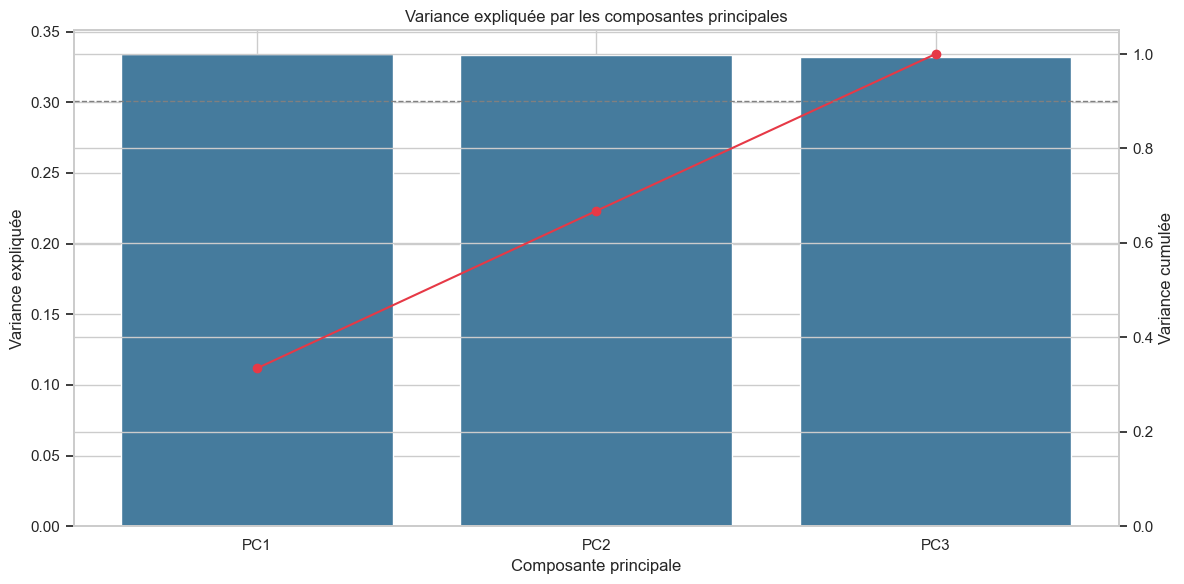

,indicateur,valeur
0,dimension_intrinseque_90pct,3.0000
1,variance_cumulee_pc2,0.6676
2,variance_cumulee_conservee,1.0000


,variable_explicative,correlation_avec_rendement
0,rainfall_mm,0.765
1,temperature_celsius,0.085
2,days_to_harvest,-0.003


,composante,variance_expliquee,variance_cumulee
0,PC1,0.3342,0.3342
1,PC2,0.3334,0.6676
2,PC3,0.3324,1.0000


Les deux premiers axes ne résument que 66.8% de la variance : l'ACP sert donc surtout à clarifier le rôle respectif de la pluie, de la température et du cycle cultural, pas à compresser fortement l'information.
Avec un seuil de 90 %, il faut 3 composantes pour conserver 100.0% de la variance totale.
Le rendement reste ici une variable de lecture externe : il n'entre pas comme variable active dans l'ACP.
Artefacts ACP sauvegardés dans : /Users/steph/Code/Python/Jupyter/OCR_Projet12/artifacts/pca


In [6]:
pca_variance = pd.DataFrame(
    {
        'composante': [f'PC{i + 1}' for i in range(len(pca_numeric_cols))],
        'variance_expliquee': pca_model.explained_variance_ratio_,
        'variance_cumulee': np.cumsum(pca_model.explained_variance_ratio_),
    }
).round(4)
pca_variance.to_csv(PCA_VARIANCE_TABLE_PATH, index=False)
display(pca_variance)

intrinsic_dimension = int(np.argmax(pca_variance['variance_cumulee'].to_numpy() >= 0.90) + 1)
variance_two_axes = float(pca_variance.loc[min(1, len(pca_variance) - 1), 'variance_cumulee'])
positions = np.arange(len(pca_variance))

fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.bar(positions, pca_variance['variance_expliquee'], color='#457b9d')
ax1.set_xlabel('Composante principale')
ax1.set_ylabel('Variance expliquée')
ax1.set_xticks(positions)
ax1.set_xticklabels(pca_variance['composante'])

ax2 = ax1.twinx()
ax2.plot(positions, pca_variance['variance_cumulee'], marker='o', color='#e63946')
ax2.axhline(0.90, linestyle='--', color='gray', linewidth=1)
ax2.set_ylabel('Variance cumulée')
ax2.set_ylim(0, 1.05)

plt.title('Variance expliquée par les composantes principales')
plt.tight_layout()
fig.savefig(PCA_VARIANCE_FIG_PATH, dpi=150, bbox_inches='tight')
plt.show()

pca_summary = pd.DataFrame(
    {
        'indicateur': [
            'dimension_intrinseque_90pct',
            'variance_cumulee_pc2',
            'variance_cumulee_conservee',
        ],
        'valeur': [
            intrinsic_dimension,
            round(variance_two_axes, 4),
            round(float(pca_variance.loc[intrinsic_dimension - 1, 'variance_cumulee']), 4),
        ],
    }
)
pca_summary.to_csv(PCA_SUMMARY_PATH, index=False)
display(pca_summary)

pca_target_links = (
    agriculture_crop_yield_clean[pca_numeric_cols + [target_col]]
    .corr()[target_col]
    .drop(target_col)
    .sort_values(key=lambda s: s.abs(), ascending=False)
    .rename('correlation_avec_rendement')
    .reset_index()
    .rename(columns={'index': 'variable_explicative'})
)
display(pca_target_links.round(3))

display(pca_variance.head(intrinsic_dimension).copy())

print(
    f"Les deux premiers axes ne résument que {variance_two_axes:.1%} de la variance : "
    "l'ACP sert donc surtout à clarifier le rôle respectif de la pluie, de la température et du cycle cultural, "
    "pas à compresser fortement l'information."
)
print(
    f"Avec un seuil de 90 %, il faut {intrinsic_dimension} composantes pour conserver "
    f"{pca_variance.loc[intrinsic_dimension - 1, 'variance_cumulee']:.1%} de la variance totale."
)
print("Le rendement reste ici une variable de lecture externe : il n'entre pas comme variable active dans l'ACP.")
print(f"Artefacts ACP sauvegardés dans : {PCA_ARTIFACTS_DIR.resolve()}")


## 3. Lecture métier complémentaire de `crop_yield.csv`

L'ACP ne couvre que les variables quantitatives explicatives. Cette section complète donc l'analyse avec une lecture directe des variables métier catégorielles et booléennes pour identifier plus complètement les facteurs associés au rendement.


Rendement moyen par culture


,crop,rendement_moyen_t_ha,rendement_median_t_ha,effectif
0,Soybean,4.655,4.658,166315
1,Wheat,4.654,4.656,166640
2,Cotton,4.652,4.651,166548
3,Rice,4.652,4.653,166754
4,Barley,4.649,4.651,166727
5,Maize,4.643,4.643,166785


Rendement moyen par type de sol


,soil_type,rendement_moyen_t_ha,rendement_median_t_ha,effectif
0,Chalky,4.654,4.662,166735
1,Loam,4.652,4.649,166757
2,Peaty,4.652,4.656,166252
3,Sandy,4.650,4.649,167081
4,Silt,4.650,4.650,166633
5,Clay,4.646,4.648,166311


Rendement moyen par région


...

,weather_condition,rendement_moyen_t_ha,rendement_median_t_ha,effectif
0,Sunny,4.653,4.655,333701
1,Rainy,4.650,4.651,333491
2,Cloudy,4.648,4.650,332577


Rendement moyen selon la fertilisation


,fertilizer_used,rendement_moyen_t_ha,rendement_median_t_ha,effectif
0,True,5.400,5.399,499940
1,False,3.901,3.905,499829


Rendement moyen selon l'irrigation


,irrigation_used,rendement_moyen_t_ha,rendement_median_t_ha,effectif
0,True,5.250,5.250,499491
1,False,4.052,4.053,500278


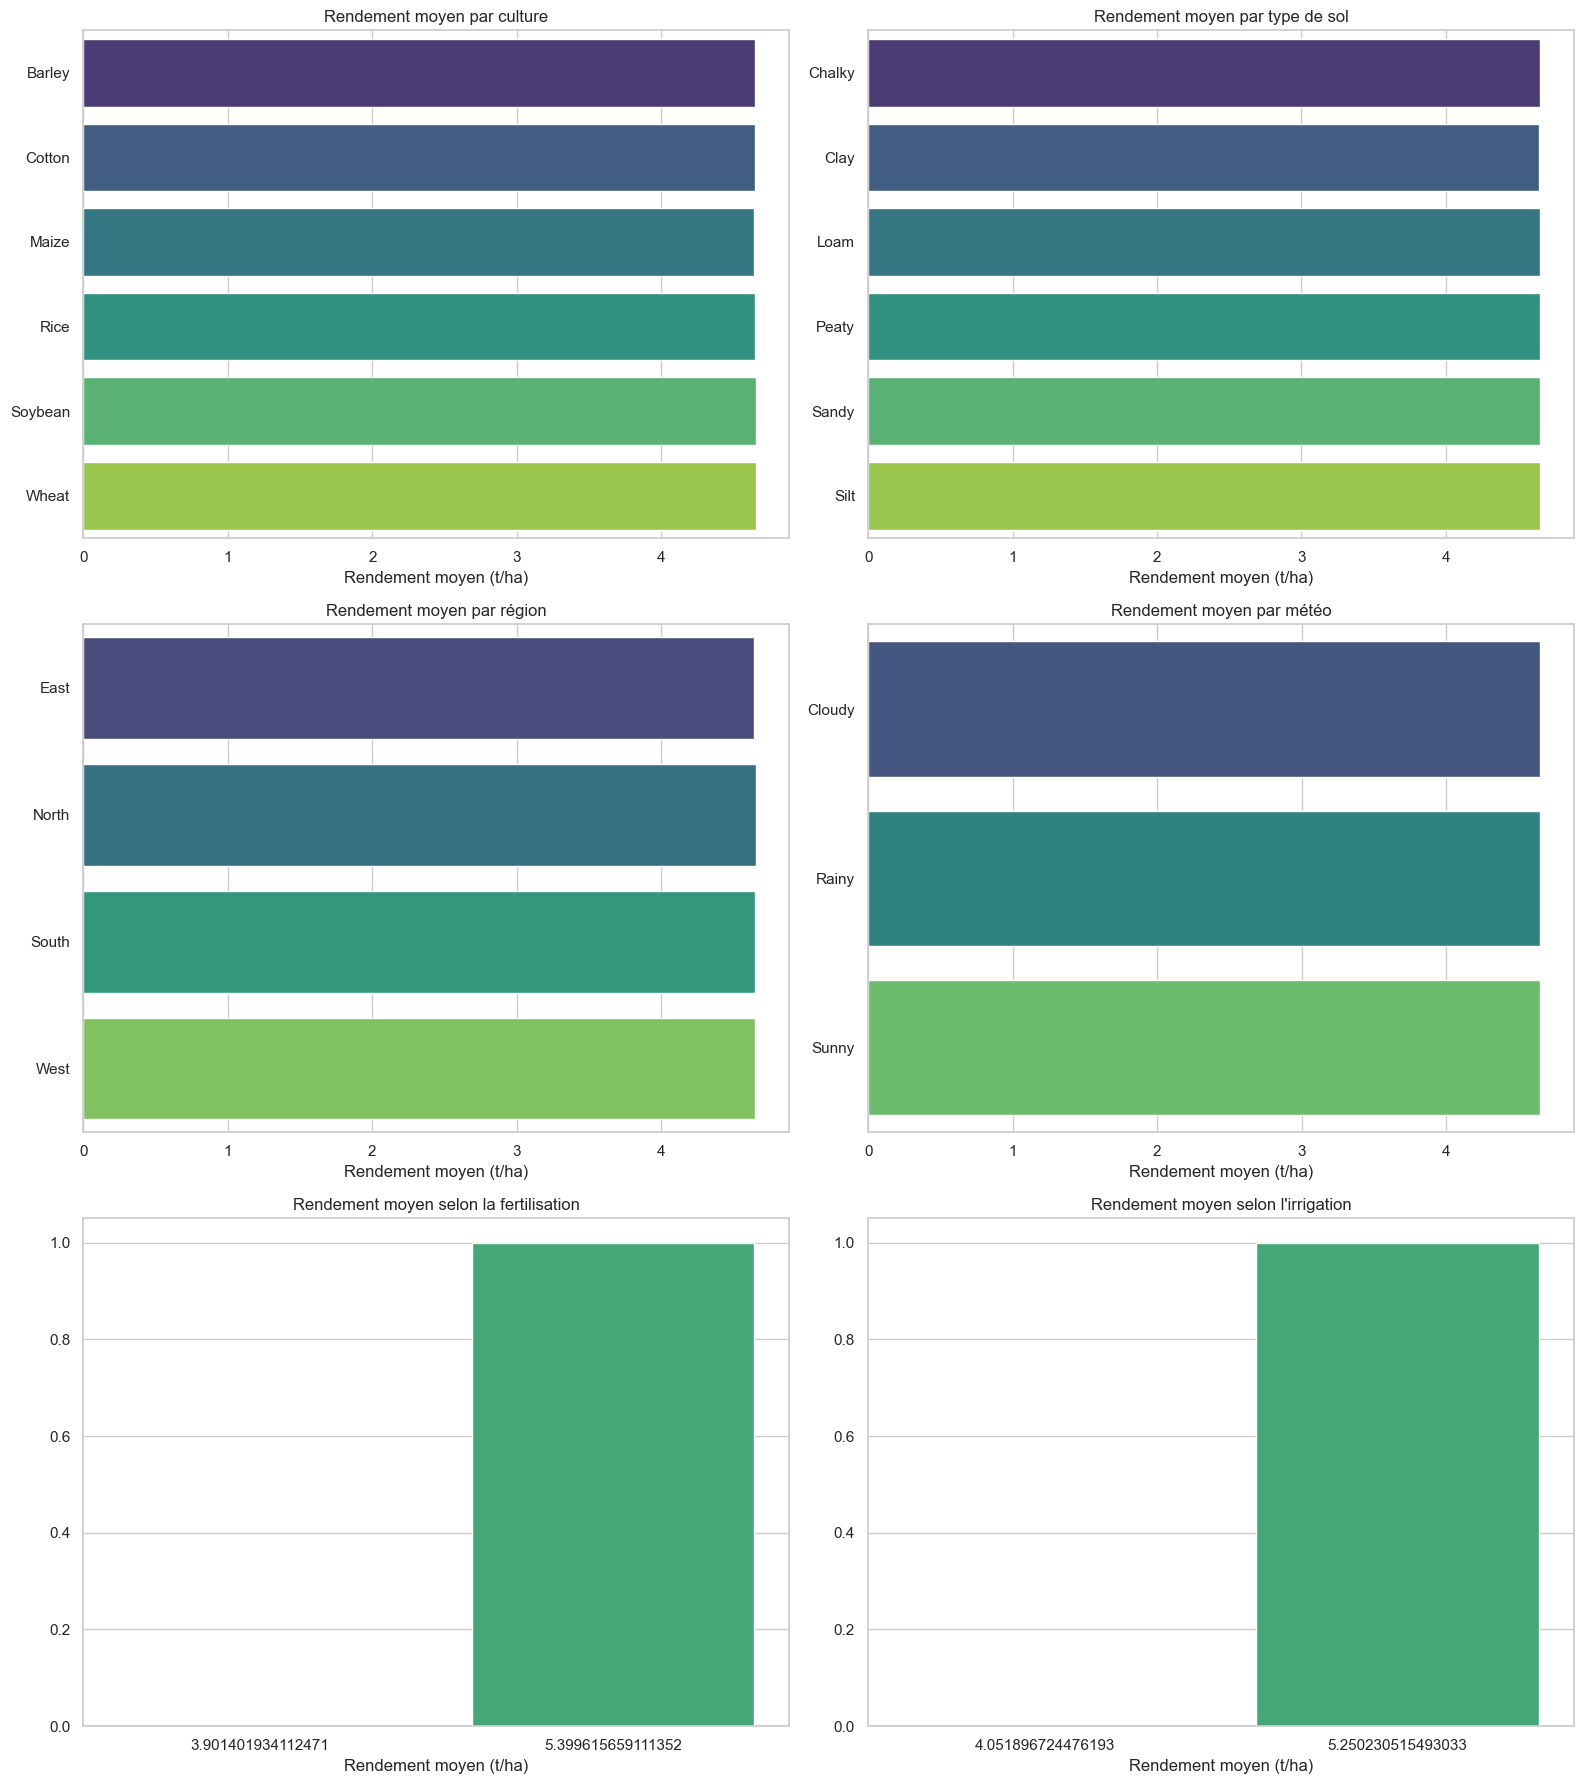

In [7]:
category_specs = [
    ('crop', 'Rendement moyen par culture'),
    ('soil_type', 'Rendement moyen par type de sol'),
    ('region', 'Rendement moyen par région'),
    ('weather_condition', 'Rendement moyen par météo'),
    ('fertilizer_used', 'Rendement moyen selon la fertilisation'),
    ('irrigation_used', "Rendement moyen selon l'irrigation"),
]

category_summaries = {}
for column, title in category_specs:
    summary = (
        agriculture_crop_yield_clean.groupby(column, observed=False)[target_col]
        .agg(['mean', 'median', 'count'])
        .sort_values('mean', ascending=False)
        .reset_index()
        .rename(columns={'mean': 'rendement_moyen_t_ha', 'median': 'rendement_median_t_ha', 'count': 'effectif'})
    )
    category_summaries[column] = summary
    print(title)
    display(summary.round(3))

fig, axes = plt.subplots(3, 2, figsize=(16, 18))

for ax, (column, title) in zip(axes.flat, category_specs):
    plot_data = category_summaries[column].copy()
    sns.barplot(
        data=plot_data,
        x='rendement_moyen_t_ha',
        y=column,
        hue=column,
        dodge=False,
        palette='viridis',
        legend=False,
        ax=ax,
    )
    ax.set_title(title)
    ax.set_xlabel('Rendement moyen (t/ha)')
    ax.set_ylabel('')

plt.tight_layout()
plt.show()


## 4. Dataset annuel : chargement des sources et scénario de fusion

Le dataset de modélisation finale est construit sur une base annuelle distincte. Le scénario retenu est le suivant :

- `yield.csv` porte la cible de rendement avec une clé propre `area + crop + year` ;
- `rainfall.csv`, `pesticides.csv` et `temp.csv` enrichissent cette base sur `area + year` ;
- `yield_df.csv` sert uniquement à auditer le résultat ;
- `crop_yield.csv` reste séparé et n'est pas injecté dans la fusion, faute de clé commune robuste.


### Pourquoi un second univers de données est nécessaire

Même si `crop_yield.csv` est très pratique pour l'analyse, il ne suffit pas pour construire une base annuelle consolidée, car il ne permet pas de rattacher chaque observation à un pays et à une année.

Le dossier `Crop Yield Prediction Dataset` apporte justement cette granularité annuelle. Chaque source y joue un rôle précis :

- `yield.csv` fournit le rendement observé par pays, culture et année ;
- `rainfall.csv` apporte la pluie moyenne annuelle ;
- `temp.csv` apporte la température moyenne annuelle ;
- `pesticides.csv` apporte un indicateur d'intrants ;
- `yield_df.csv` sert de point de contrôle, car il ressemble à une table déjà enrichie.

Autrement dit, `crop_yield.csv` aide à **comprendre** le rendement, tandis que les tables annuelles aident à **construire** la base du modèle.


In [8]:
source_paths = {
    "yield.csv": YIELD_PATH,
    "rainfall.csv": RAINFALL_PATH,
    "pesticides.csv": PESTICIDES_PATH,
    "temp.csv": TEMP_PATH,
    "yield_df.csv": YIELD_DF_AUDIT_PATH,
}

missing_source_files = [name for name, path in source_paths.items() if not path.exists()]
if missing_source_files:
    raise FileNotFoundError(f"Fichiers introuvables : {missing_source_files}")

yield_source = pd.read_csv(YIELD_PATH)
rainfall_source = pd.read_csv(RAINFALL_PATH, na_values=[".."])
pesticides_source = pd.read_csv(PESTICIDES_PATH)
temp_source = pd.read_csv(TEMP_PATH)
yield_df_source = pd.read_csv(YIELD_DF_AUDIT_PATH)

source_overview = pd.DataFrame(
    [
        {
            "fichier": "yield.csv",
            "lignes": yield_source.shape[0],
            "colonnes": yield_source.shape[1],
            "nan_detectes": int(yield_source.isna().sum().sum()),
        },
        {
            "fichier": "rainfall.csv",
            "lignes": rainfall_source.shape[0],
            "colonnes": rainfall_source.shape[1],
            "nan_detectes": int(rainfall_source.isna().sum().sum()),
        },
        {
            "fichier": "pesticides.csv",
            "lignes": pesticides_source.shape[0],
            "colonnes": pesticides_source.shape[1],
            "nan_detectes": int(pesticides_source.isna().sum().sum()),
        },
        {
            "fichier": "temp.csv",
            "lignes": temp_source.shape[0],
            "colonnes": temp_source.shape[1],
            "nan_detectes": int(temp_source.isna().sum().sum()),
        },
        {
            "fichier": "yield_df.csv",
            "lignes": yield_df_source.shape[0],
            "colonnes": yield_df_source.shape[1],
            "nan_detectes": int(yield_df_source.isna().sum().sum()),
        },
    ]
)

display(source_overview)


,fichier,lignes,colonnes,nan_detectes
0,yield.csv,56717,12,0
1,rainfall.csv,6727,3,780
2,pesticides.csv,4349,7,0
3,temp.csv,71311,3,2547
4,yield_df.csv,28242,8,0


### Nettoyage et harmonisation des tables annuelles

Les transformations ci-dessous restent strictement dans le périmètre de l'étape 1 : harmonisation des noms de colonnes, conversion des mesures en numérique, filtrage temporel à partir de `1990`, agrégation des doublons de `temp.csv`, et normalisation de la cible de rendement en `t/ha`.


In [9]:
yield_clean = (
    yield_source.loc[:, ["Area", "Item", "Year", "Unit", "Value"]]
    .rename(
        columns={
            "Area": "area",
            "Item": "crop",
            "Year": "year",
            "Unit": "yield_unit",
            "Value": "yield_hg_ha",
        }
    )
    .assign(
        area=lambda df: df["area"].astype("string").str.strip(),
        crop=lambda df: df["crop"].astype("string").str.strip(),
        year=lambda df: pd.to_numeric(df["year"], errors="raise").astype(int),
        yield_hg_ha=lambda df: pd.to_numeric(df["yield_hg_ha"], errors="coerce"),
    )
)
yield_before_filter = len(yield_clean)
yield_clean = yield_clean.loc[yield_clean["year"] >= MIN_YEAR].copy()

yield_units = sorted(yield_clean["yield_unit"].dropna().astype(str).unique().tolist())
print(f"Unités observées dans yield.csv : {yield_units}")

yield_clean["target_yield_t_ha"] = yield_clean["yield_hg_ha"] / 10000
yield_clean = yield_clean.drop(columns=["yield_unit", "yield_hg_ha"])

rainfall_clean = (
    rainfall_source.rename(columns={" Area": "Area"})
    .loc[:, ["Area", "Year", "average_rain_fall_mm_per_year"]]
    .rename(columns={"Area": "area", "Year": "year"})
    .assign(
        area=lambda df: df["area"].astype("string").str.strip(),
        year=lambda df: pd.to_numeric(df["year"], errors="raise").astype(int),
        average_rain_fall_mm_per_year=lambda df: pd.to_numeric(
            df["average_rain_fall_mm_per_year"], errors="coerce"
        ),
    )
)
rainfall_before_filter = len(rainfall_clean)
rainfall_clean = rainfall_clean.loc[rainfall_clean["year"] >= MIN_YEAR].copy()

pesticides_clean = (
    pesticides_source.loc[:, ["Area", "Year", "Value"]]
    .rename(columns={"Area": "area", "Year": "year", "Value": "pesticides_tonnes"})
    .assign(
        area=lambda df: df["area"].astype("string").str.strip(),
        year=lambda df: pd.to_numeric(df["year"], errors="raise").astype(int),
        pesticides_tonnes=lambda df: pd.to_numeric(df["pesticides_tonnes"], errors="coerce"),
    )
)
pesticides_before_filter = len(pesticides_clean)
pesticides_clean = pesticides_clean.loc[pesticides_clean["year"] >= MIN_YEAR].copy()

temp_clean = (
    temp_source.rename(columns={"country": "Area", "year": "Year"})
    .loc[:, ["Area", "Year", "avg_temp"]]
    .rename(columns={"Area": "area", "Year": "year"})
    .assign(
        area=lambda df: df["area"].astype("string").str.strip(),
        year=lambda df: pd.to_numeric(df["year"], errors="raise").astype(int),
        avg_temp=lambda df: pd.to_numeric(df["avg_temp"], errors="coerce"),
    )
)
temp_before_filter = len(temp_clean)
temp_clean = (
    temp_clean.loc[temp_clean["year"] >= MIN_YEAR]
    .copy()
    .groupby(["area", "year"], as_index=False)["avg_temp"]
    .mean()
)

yield_df_audit_clean = (
    yield_df_source.loc[
        :,
        [
            "Area",
            "Item",
            "Year",
            "hg/ha_yield",
            "average_rain_fall_mm_per_year",
            "pesticides_tonnes",
            "avg_temp",
        ],
    ]
    .rename(
        columns={
            "Area": "area",
            "Item": "crop",
            "Year": "year",
            "hg/ha_yield": "yield_hg_ha",
        }
    )
    .assign(
        area=lambda df: df["area"].astype("string").str.strip(),
        crop=lambda df: df["crop"].astype("string").str.strip(),
        year=lambda df: pd.to_numeric(df["year"], errors="raise").astype(int),
        yield_hg_ha=lambda df: pd.to_numeric(df["yield_hg_ha"], errors="coerce"),
        average_rain_fall_mm_per_year=lambda df: pd.to_numeric(
            df["average_rain_fall_mm_per_year"], errors="coerce"
        ),
        pesticides_tonnes=lambda df: pd.to_numeric(df["pesticides_tonnes"], errors="coerce"),
        avg_temp=lambda df: pd.to_numeric(df["avg_temp"], errors="coerce"),
    )
)
yield_df_audit_before_filter = len(yield_df_audit_clean)
yield_df_audit_clean = yield_df_audit_clean.loc[yield_df_audit_clean["year"] >= MIN_YEAR].copy()
yield_df_audit_clean["target_yield_t_ha"] = yield_df_audit_clean["yield_hg_ha"] / 10000

year_filter_summary = pd.DataFrame(
    [
        {
            "table": "yield_clean",
            "annee_min": int(pd.to_numeric(yield_source["Year"], errors="coerce").min()),
            "annee_max": int(pd.to_numeric(yield_source["Year"], errors="coerce").max()),
            "lignes_supprimees_avant_1990": yield_before_filter - len(yield_clean),
        },
        {
            "table": "rainfall_clean",
            "annee_min": int(pd.to_numeric(rainfall_source["Year"], errors="coerce").min()),
            "annee_max": int(pd.to_numeric(rainfall_source["Year"], errors="coerce").max()),
            "lignes_supprimees_avant_1990": rainfall_before_filter - len(rainfall_clean),
        },
        {
            "table": "pesticides_clean",
            "annee_min": int(pd.to_numeric(pesticides_source["Year"], errors="coerce").min()),
            "annee_max": int(pd.to_numeric(pesticides_source["Year"], errors="coerce").max()),
            "lignes_supprimees_avant_1990": pesticides_before_filter - len(pesticides_clean),
        },
        {
            "table": "temp_clean",
            "annee_min": int(pd.to_numeric(temp_source["year"], errors="coerce").min()),
            "annee_max": int(pd.to_numeric(temp_source["year"], errors="coerce").max()),
            "lignes_supprimees_avant_1990": temp_before_filter - len(temp_source.loc[pd.to_numeric(temp_source["year"], errors="coerce") >= MIN_YEAR]),
        },
        {
            "table": "yield_df_audit_clean",
            "annee_min": int(pd.to_numeric(yield_df_source["Year"], errors="coerce").min()),
            "annee_max": int(pd.to_numeric(yield_df_source["Year"], errors="coerce").max()),
            "lignes_supprimees_avant_1990": yield_df_audit_before_filter - len(yield_df_audit_clean),
        },
    ]
)

display(year_filter_summary)

source_quality = pd.DataFrame(
    [
        {
            "table": "yield_clean",
            "clé": "area + crop + year",
            "doublons_sur_cle": int(yield_clean.duplicated(subset=["area", "crop", "year"]).sum()),
            "nan_totaux": int(yield_clean.isna().sum().sum()),
        },
        {
            "table": "rainfall_clean",
            "clé": "area + year",
            "doublons_sur_cle": int(rainfall_clean.duplicated(subset=["area", "year"]).sum()),
            "nan_totaux": int(rainfall_clean.isna().sum().sum()),
        },
        {
            "table": "pesticides_clean",
            "clé": "area + year",
            "doublons_sur_cle": int(pesticides_clean.duplicated(subset=["area", "year"]).sum()),
            "nan_totaux": int(pesticides_clean.isna().sum().sum()),
        },
        {
            "table": "temp_clean",
            "clé": "area + year",
            "doublons_sur_cle": int(temp_clean.duplicated(subset=["area", "year"]).sum()),
            "nan_totaux": int(temp_clean.isna().sum().sum()),
        },
        {
            "table": "yield_df_audit_clean",
            "clé": "area + crop + year",
            "doublons_sur_cle": int(yield_df_audit_clean.duplicated(subset=["area", "crop", "year"]).sum()),
            "nan_totaux": int(yield_df_audit_clean.isna().sum().sum()),
        },
    ]
)

display(source_quality)

assert yield_clean.duplicated(subset=["area", "crop", "year"]).sum() == 0
assert rainfall_clean.duplicated(subset=["area", "year"]).sum() == 0
assert pesticides_clean.duplicated(subset=["area", "year"]).sum() == 0
assert temp_clean.duplicated(subset=["area", "year"]).sum() == 0


Unités observées dans yield.csv : ['hg/ha']


,table,annee_min,annee_max,lignes_supprimees_avant_1990
0,yield_clean,1961,2016,27350
1,rainfall_clean,1985,2017,868
2,pesticides_clean,1990,2016,0
3,temp_clean,1743,2013,63031
4,yield_df_audit_clean,1990,2013,0


,table,clé,doublons_sur_cle,nan_totaux
0,yield_clean,area + crop + year,0,0
1,rainfall_clean,area + year,0,677
2,pesticides_clean,area + year,0,0
3,temp_clean,area + year,0,0
4,yield_df_audit_clean,area + crop + year,15112,0


## 5. Construction du dataset consolidé annuel

Le dataset consolidé produit ici devient la source de vérité opérationnelle pour la modélisation. Il est construit uniquement à partir des tables annuelles cohérentes entre elles.


### Ce que représente une ligne du dataset consolidé

À partir de cette étape, chaque ligne du dataset final représente une observation annuelle de rendement pour un triplet :

- un pays ou territoire (`area`) ;
- une culture (`crop`) ;
- une année (`year`).

Les autres colonnes décrivent le contexte annuel associé à cette observation : pluie, pesticides et température moyenne.

Pour un lecteur métier, c'est un point important : on ne travaille plus ici sur des observations synthétiques génériques, mais sur des observations annuelles comparables entre pays, cultures et périodes.


In [10]:
dataset_consolide = (
    yield_clean.merge(rainfall_clean, on=["area", "year"], how="left", validate="m:1")
    .merge(pesticides_clean, on=["area", "year"], how="left", validate="m:1")
    .merge(temp_clean, on=["area", "year"], how="left", validate="m:1")
    .loc[
        :,
        [
            "area",
            "crop",
            "year",
            "target_yield_t_ha",
            "average_rain_fall_mm_per_year",
            "pesticides_tonnes",
            "avg_temp",
        ],
    ]
    .sort_values(["area", "crop", "year"])
    .reset_index(drop=True)
)

duplicate_row_count = int(dataset_consolide.duplicated().sum())
duplicate_key_count = int(dataset_consolide.duplicated(subset=["area", "crop", "year"]).sum())

consolidation_summary = pd.DataFrame(
    {
        "indicateur": [
            "Nombre de lignes",
            "Nombre de colonnes",
            "Année minimale",
            "Année maximale",
            "Lignes totalement renseignées",
            "Part des lignes totalement renseignées (%)",
            "Doublons complets",
            "Doublons sur area + crop + year",
        ],
        "valeur": [
            int(dataset_consolide.shape[0]),
            int(dataset_consolide.shape[1]),
            int(dataset_consolide["year"].min()),
            int(dataset_consolide["year"].max()),
            int(dataset_consolide.notna().all(axis=1).sum()),
            round(dataset_consolide.notna().all(axis=1).mean() * 100, 2),
            duplicate_row_count,
            duplicate_key_count,
        ],
    }
)

missing_summary = (
    dataset_consolide.isna()
    .sum()
    .rename("nb_nan")
    .reset_index()
    .rename(columns={"index": "variable"})
)
missing_summary["part_nan_pct"] = (
    missing_summary["nb_nan"] / len(dataset_consolide) * 100
).round(2)

dtype_summary = (
    dataset_consolide.dtypes.astype(str)
    .rename("dtype")
    .reset_index()
    .rename(columns={"index": "variable"})
)

display(consolidation_summary)
display(missing_summary)
display(dtype_summary)
display(dataset_consolide.head())

assert duplicate_key_count == 0

DATASET_PATH.parent.mkdir(parents=True, exist_ok=True)
dataset_consolide.to_csv(DATASET_PATH, index=False)
print(f"Dataset consolidé sauvegardé : {DATASET_PATH.resolve()}")


,indicateur,valeur
0,Nombre de lignes,29367.00
1,Nombre de colonnes,7.00
2,Année minimale,1990.00
3,Année maximale,2016.00
4,Lignes totalement renseignées,13130.00
5,Part des lignes totalement renseignées (%),44.71
6,Doublons complets,0.00
7,Doublons sur area + crop + year,0.00


,variable,nb_nan,part_nan_pct
0,area,0,0.00
1,crop,0,0.00
2,year,0,0.00
3,target_yield_t_ha,0,0.00
4,average_rain_fall_mm_per_year,6995,23.82
5,pesticides_tonnes,5214,17.75
6,avg_temp,13570,46.21


,variable,dtype
0,area,string
1,crop,string
2,year,int64
3,target_yield_t_ha,float64
4,average_rain_fall_mm_per_year,float64
5,pesticides_tonnes,float64
6,avg_temp,float64


,area,crop,year,target_yield_t_ha,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,Afghanistan,Maize,1990,1.7582,327.0,NaN,15.45
1,Afghanistan,Maize,1991,1.6800,327.0,NaN,14.57
2,Afghanistan,Maize,1992,1.5000,327.0,NaN,14.35
3,Afghanistan,Maize,1993,1.6786,327.0,NaN,14.96
4,Afghanistan,Maize,1994,1.6667,327.0,NaN,14.94


Dataset consolidé sauvegardé : /Users/steph/Code/Python/Jupyter/OCR_Projet12/data/dataset_consolide.csv


## 6. Valeurs manquantes et couverture des jointures

Les valeurs manquantes restantes du dataset consolidé sont étudiées ici en distinguant :

- les manques hérités des sources ;
- les non-correspondances de jointure entre la table de base et les tables d'enrichissement.

Le choix retenu à ce stade est de conserver ces lignes et de traiter l'imputation plus tard dans le pipeline de modélisation.


### Comment interpréter les valeurs manquantes

Des valeurs manquantes dans le dataset consolidé ne veulent pas dire que la ligne de rendement est inutilisable. Elles signifient plus précisément qu'une information d'enrichissement n'a pas pu être retrouvée pour cette combinaison `area + year`.

D'un point de vue métier, cela indique une couverture inégale des sources externes, pas une absence totale d'information sur la culture ou sur le rendement.

Le choix retenu ici est pragmatique : on conserve ces observations pour ne pas perdre inutilement de données de rendement, puis on traitera l'imputation plus tard dans le pipeline de modélisation.


In [11]:
base_keys = yield_clean[['area', 'year']].drop_duplicates()

source_missing_after_filter = pd.DataFrame(
    [
        {
            'source': 'rainfall_clean',
            'variable': 'average_rain_fall_mm_per_year',
            'nan_dans_source_apres_filtre': int(rainfall_clean['average_rain_fall_mm_per_year'].isna().sum()),
        },
        {
            'source': 'pesticides_clean',
            'variable': 'pesticides_tonnes',
            'nan_dans_source_apres_filtre': int(pesticides_clean['pesticides_tonnes'].isna().sum()),
        },
        {
            'source': 'temp_clean',
            'variable': 'avg_temp',
            'nan_dans_source_apres_filtre': int(temp_clean['avg_temp'].isna().sum()),
        },
    ]
)

def unmatched_base_keys(enrichment_df):
    coverage = base_keys.merge(
        enrichment_df[['area', 'year']].drop_duplicates().assign(match=True),
        on=['area', 'year'],
        how='left',
    )
    return int(coverage['match'].isna().sum())

key_coverage_summary = pd.DataFrame(
    [
        {
            'source': 'rainfall_clean',
            'cles_base_sans_correspondance': unmatched_base_keys(rainfall_clean),
        },
        {
            'source': 'pesticides_clean',
            'cles_base_sans_correspondance': unmatched_base_keys(pesticides_clean),
        },
        {
            'source': 'temp_clean',
            'cles_base_sans_correspondance': unmatched_base_keys(temp_clean),
        },
    ]
)
key_coverage_summary['part_cles_sans_correspondance_pct'] = (
    key_coverage_summary['cles_base_sans_correspondance'] / len(base_keys) * 100
).round(2)

dataset_missing_profile = pd.DataFrame(
    [
        {
            'indicateur': 'Lignes avec au moins une valeur manquante',
            'valeur': int(dataset_consolide.isna().any(axis=1).sum()),
        },
        {
            'indicateur': 'Lignes complètement renseignées',
            'valeur': int(dataset_consolide.notna().all(axis=1).sum()),
        },
    ]
)

display(source_missing_after_filter)
display(key_coverage_summary)
display(dataset_missing_profile)


,source,variable,nan_dans_source_apres_filtre
0,rainfall_clean,average_rain_fall_mm_per_year,677
1,pesticides_clean,pesticides_tonnes,0
2,temp_clean,avg_temp,0


,source,cles_base_sans_correspondance,part_cles_sans_correspondance_pct
0,rainfall_clean,1148,21.22
1,pesticides_clean,1093,20.20
2,temp_clean,2678,49.49


,indicateur,valeur
0,Lignes avec au moins une valeur manquante,16237
1,Lignes complètement renseignées,13130


## 7. Audit final avec `yield_df.csv`

`yield_df.csv` n'est pas utilisé pour fabriquer la table finale. Il sert ici à vérifier que le scénario de fusion retenu reconstruit correctement, sur les clés communes, les facteurs annuels déjà présents dans ce fichier enrichi.


### Pourquoi auditer avec `yield_df.csv`

Cet audit sert à vérifier que la fusion construite à partir des tables annuelles retrouve bien, sur les clés communes, les mêmes ordres de grandeur que dans un fichier déjà enrichi.

Pour un profil métier, cet audit joue le rôle d'un contrôle de cohérence : il permet de s'assurer que le dataset consolidé n'est pas seulement techniquement fusionné, mais aussi crédible dans son contenu.


In [12]:
yield_df_audit_unique = (
    yield_df_audit_clean.groupby(["area", "crop", "year"], as_index=False)[
        [
            "target_yield_t_ha",
            "average_rain_fall_mm_per_year",
            "pesticides_tonnes",
            "avg_temp",
        ]
    ].mean()
)

audit_overlap = dataset_consolide.merge(
    yield_df_audit_unique,
    on=["area", "crop", "year"],
    how="inner",
    suffixes=("_built", "_audit"),
)

audit_summary = pd.DataFrame(
    [
        {
            "controle": "Clés communes sur area + crop + year",
            "valeur": int(audit_overlap.shape[0]),
        },
        {
            "controle": "Écart absolu moyen sur la cible (t/ha)",
            "valeur": audit_overlap["target_yield_t_ha_built"]
            .sub(audit_overlap["target_yield_t_ha_audit"])
            .abs()
            .mean(),
        },
        {
            "controle": "Écart absolu moyen sur la pluie",
            "valeur": audit_overlap["average_rain_fall_mm_per_year_built"]
            .sub(audit_overlap["average_rain_fall_mm_per_year_audit"])
            .abs()
            .mean(),
        },
        {
            "controle": "Écart absolu moyen sur les pesticides",
            "valeur": audit_overlap["pesticides_tonnes_built"]
            .sub(audit_overlap["pesticides_tonnes_audit"])
            .abs()
            .mean(),
        },
        {
            "controle": "Écart absolu moyen sur la température",
            "valeur": audit_overlap["avg_temp_built"].sub(audit_overlap["avg_temp_audit"]).abs().mean(),
        },
    ]
)

display(audit_summary.round(4))

print("Validation du scénario de fusion : les variables annuelles reconstruites sont ensuite relues dans le rapport comme confirmation des facteurs pressentis en amont.")


,controle,valeur
0,Clés communes sur area + crop + year,13130.0
1,Écart absolu moyen sur la cible (t/ha),0.0
2,Écart absolu moyen sur la pluie,0.0
3,Écart absolu moyen sur les pesticides,0.0
4,Écart absolu moyen sur la température,0.0


Validation du scénario de fusion : les variables annuelles reconstruites sont ensuite relues dans le rapport comme confirmation des facteurs pressentis en amont.


## 8. Conclusion opérationnelle

La séparation retenue dans ce notebook est désormais explicite :

- `crop_yield.csv` sert à l'analyse explicative, au nettoyage amont et à l'ACP ;
- `yield.csv + rainfall.csv + pesticides.csv + temp.csv` servent à construire le dataset consolidé annuel de modélisation ;
- `yield_df.csv` sert à l'audit final ;
- les composantes ACP ne sont pas utilisées comme variables d'entrée du modèle ;
- le dataset final sauvegardé ici devient l'entrée unique de `modelisation.ipynb`.
